# Segmentasi Nasabah Kartu Kredit dengan K-Means (CRISP-DM)
**Mata Kuliah:** Data Science – Pertemuan 4, Semester 7  
**Nama / NIM:** _(isi di sini)_

Notebook ini mengikuti tahapan CRISP-DM: Business Understanding → Data Understanding → Data Preparation → Modeling → Evaluation → Deployment (aplikasi Streamlit pada `app.py`).

## 1. Business Understanding
**Latar belakang.** Penerbit kartu kredit memiliki ribuan nasabah dengan perilaku berbeda (ada yang rutin belanja, ada yang sering tarik tunai, ada yang jarang memakai kartu). Perlakuan promosi yang sama untuk semua nasabah tidak efisien.

**Tujuan bisnis.** Mengelompokkan nasabah berdasarkan perilaku penggunaan kartu agar tim pemasaran/risiko dapat menyusun strategi berbeda per kelompok.

**Tujuan data mining.** Menerapkan *clustering* (K-Means, dibandingkan dengan Agglomerative) pada fitur perilaku transaksi, menentukan jumlah klaster optimal, lalu menginterpretasikan profil tiap klaster.

**Kriteria keberhasilan.** Klaster terpisah cukup baik (Silhouette Score, Davies-Bouldin, Calinski-Harabasz) *dan* dapat diinterpretasikan secara bisnis.

## 2. Data Understanding
**Sumber dataset:** *Credit Card Dataset for Clustering* (Kaggle, oleh Arjun Bhasin) – https://www.kaggle.com/datasets/arjunbhasin2013/ccdata  
Berkas: `CC GENERAL.csv`, ±8.950 baris × 18 kolom (perlu dikonfirmasi ulang saat Anda mengunduhnya; cek output `df.shape` di bawah).

**Alasan cocok untuk clustering:** (1) tidak memiliki label target, sehingga bersifat *unsupervised*; (2) banyak fitur numerik perilaku (saldo, pembelian, tarik tunai, frekuensi); (3) secara bisnis lazim dipakai untuk segmentasi nasabah; (4) memenuhi syarat ≥1000 baris, ≥8 kolom, dan ≥3 fitur numerik.

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import joblib
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import warnings; warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
RANDOM_STATE = 42

In [7]:
DATA_PATH = 'CC_GENERAL.csv'   # ubah jika nama berkas Anda berbeda
df = pd.read_csv(DATA_PATH)
print('Ukuran data:', df.shape)
df.head()

Ukuran data: (8950, 18)


,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [8]:
df.info()
print('\nMissing value per kolom:'); print(df.isna().sum()[df.isna().sum() > 0])
print('\nBaris duplikat:', df.duplicated().sum())
df.describe().T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

,count,mean,std,min,25%,50%,75%,max
BALANCE,8950.0,1564.474828,2081.531879,0.000000,128.281915,873.385231,2054.140036,19043.13856
BALANCE_FREQUENCY,8950.0,0.877271,0.236904,0.000000,0.888889,1.000000,1.000000,1.00000
PURCHASES,8950.0,1003.204834,2136.634782,0.000000,39.635000,361.280000,1110.130000,49039.57000
ONEOFF_PURCHASES,8950.0,592.437371,1659.887917,0.000000,0.000000,38.000000,577.405000,40761.25000
INSTALLMENTS_PURCHASES,8950.0,411.067645,904.338115,0.000000,0.000000,89.000000,468.637500,22500.00000
CASH_ADVANCE,8950.0,978.871112,2097.163877,0.000000,0.000000,0.000000,1113.821139,47137.21176
PURCHASES_FREQUENCY,8950.0,0.490351,0.401371,0.000000,0.083333,0.500000,0.916667,1.00000
ONEOFF_PURCHASES_FREQUENCY,8950.0,0.202458,0.298336,0.000000,0.000000,0.083333,0.300000,1.00000
PURCHASES_INSTALLMENTS_FREQUENCY,8950.0,0.364437,0.397448,0.000000,0.000000,0.166667,0.750000,1.00000
CASH_ADVANCE_FREQUENCY,8950.0,0.135144,0.200121,0.000000,0.000000,0.000000,0.222222,1.50000


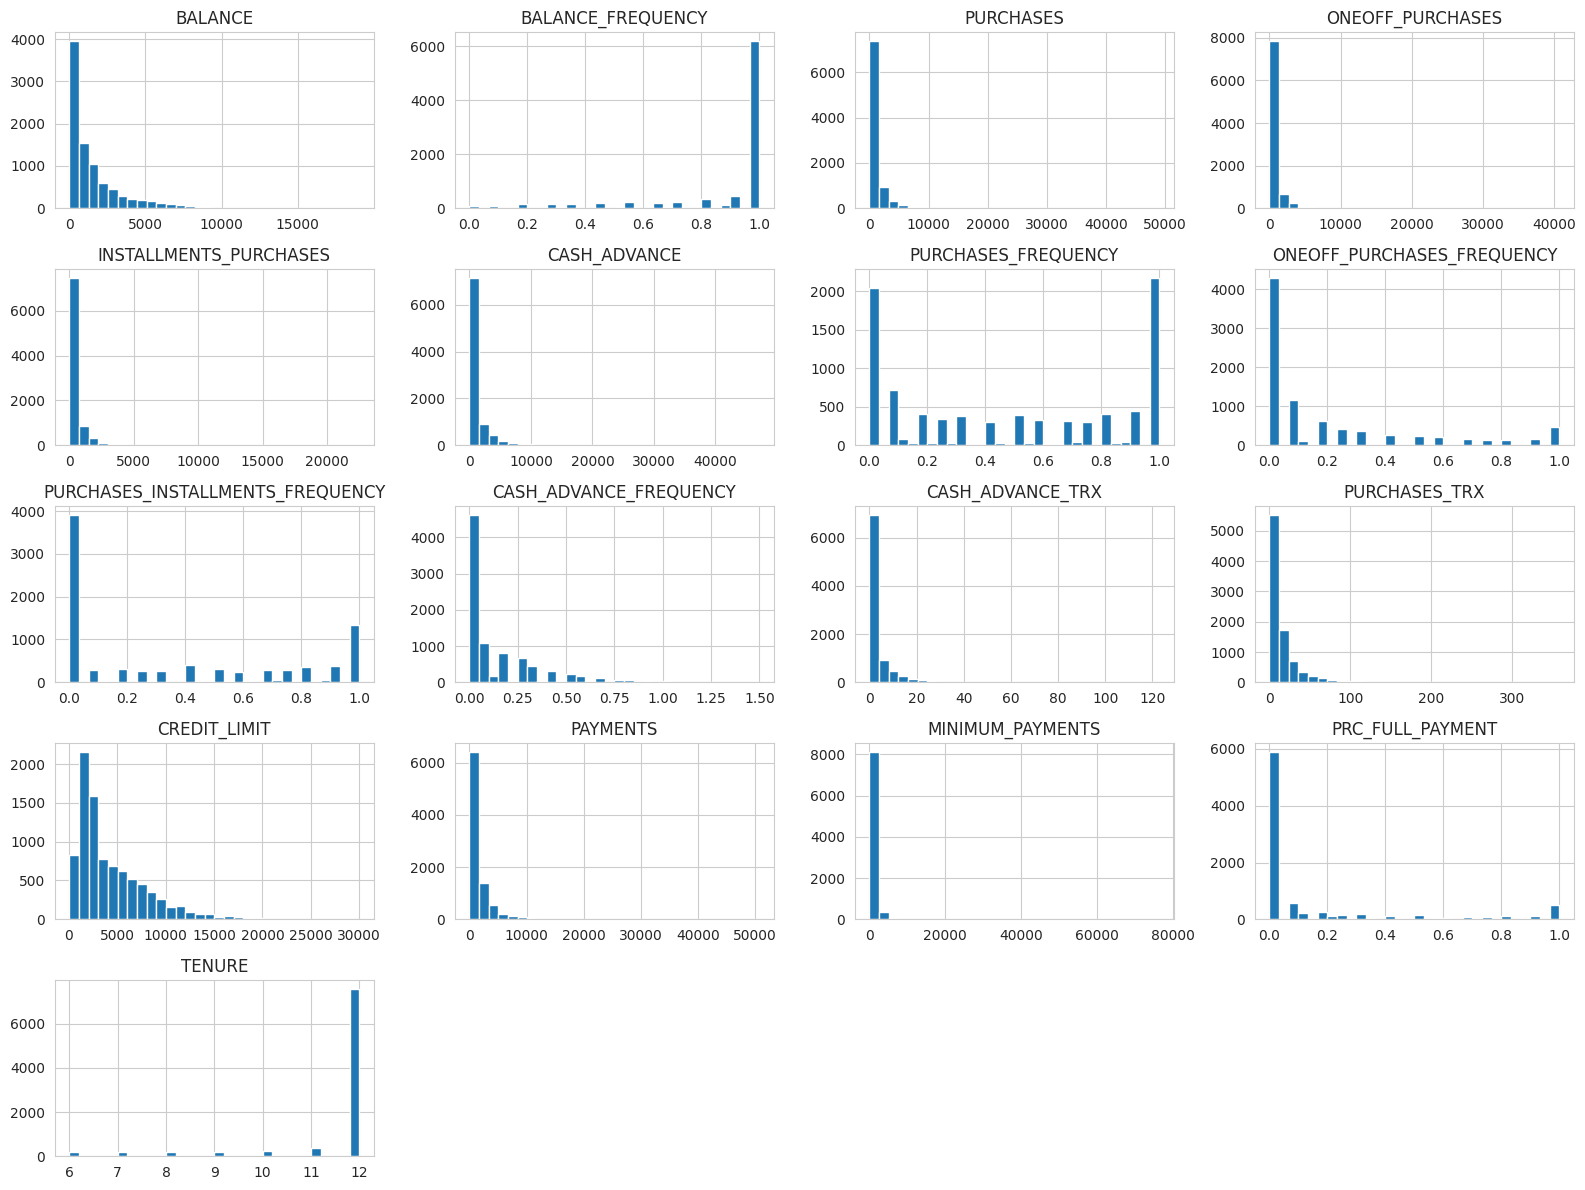

In [9]:
# Distribusi fitur numerik (banyak yang miring ke kanan -> pertimbangan transformasi log)
num_cols = df.select_dtypes(include=np.number).columns
df[num_cols].hist(bins=30, figsize=(16, 12)); plt.tight_layout(); plt.show()

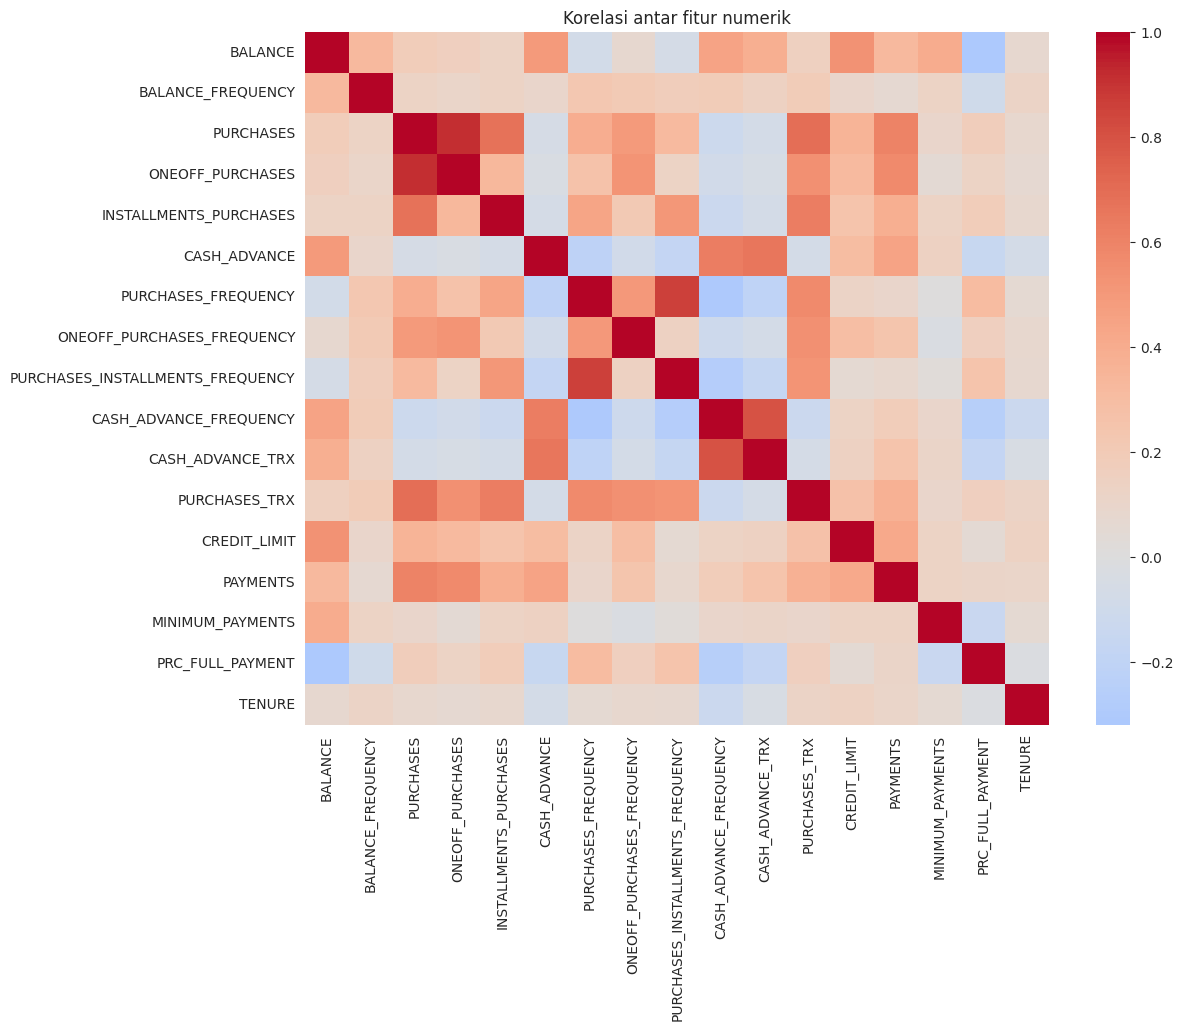

In [10]:
plt.figure(figsize=(12, 9))
sns.heatmap(df[num_cols].corr(), cmap='coolwarm', center=0, annot=False)
plt.title('Korelasi antar fitur numerik'); plt.show()

## 3. Data Preparation
Keputusan yang diambil (asumsi, dapat Anda ubah dan jelaskan di laporan):
- `CUST_ID` dibuang (hanya identitas).
- Dipilih 8 fitur perilaku yang tidak terlalu redundan: `BALANCE, PURCHASES, CASH_ADVANCE, CREDIT_LIMIT, PAYMENTS, PURCHASES_FREQUENCY, CASH_ADVANCE_FREQUENCY, PRC_FULL_PAYMENT`.
- Missing value diisi median (pipeline `SimpleImputer`).
- Fitur bernilai uang bersifat sangat miring → `log1p`, lalu `StandardScaler` karena K-Means berbasis jarak.
- Outlier **tidak dihapus**; nasabah bernilai ekstrem justru bisa menjadi segmen bisnis yang penting. Log transform meredam pengaruhnya.

In [11]:
FEATURES = ['BALANCE','PURCHASES','CASH_ADVANCE','CREDIT_LIMIT','PAYMENTS',
            'PURCHASES_FREQUENCY','CASH_ADVANCE_FREQUENCY','PRC_FULL_PAYMENT']
X = df[FEATURES].copy()
prep = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('log', FunctionTransformer(np.log1p, feature_names_out='one-to-one')),
    ('scaler', StandardScaler()),
])
X_scaled = prep.fit_transform(X)
print(X_scaled.shape)

(8950, 8)


## 4. Modeling

### 4.1 Menentukan jumlah klaster (Elbow & Silhouette)

,k,inertia,silhouette,davies_bouldin,calinski_harabasz
0,2,49702.869,0.294,1.412,3942.139
1,3,41985.683,0.269,1.320,3155.356
2,4,35096.160,0.278,1.323,3101.613
3,5,30226.658,0.282,1.292,3060.912
4,6,27475.126,0.267,1.250,2872.805
5,7,25177.937,0.244,1.266,2748.132
6,8,23085.033,0.246,1.283,2684.621
7,9,21587.302,0.247,1.314,2589.275
8,10,20320.228,0.243,1.323,2506.762


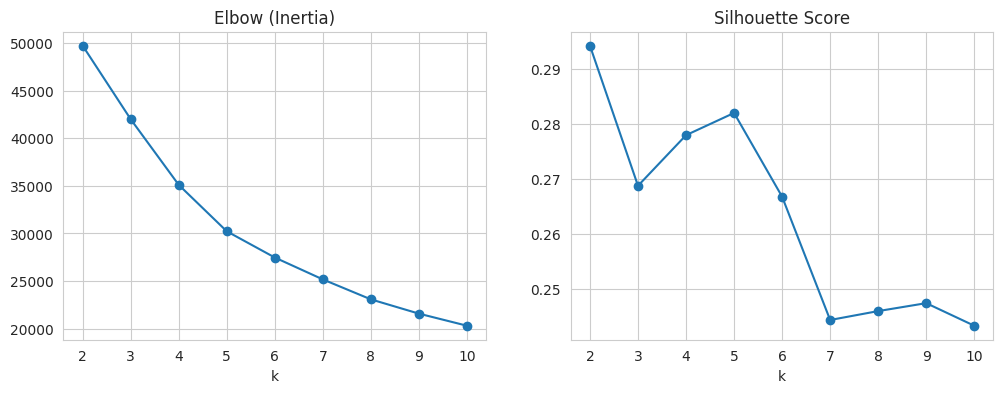

In [12]:
ks = range(2, 11)
inertia, sil, dbi, chi = [], [], [], []
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(X_scaled)
    inertia.append(km.inertia_)
    sil.append(silhouette_score(X_scaled, km.labels_, sample_size=5000, random_state=RANDOM_STATE))
    dbi.append(davies_bouldin_score(X_scaled, km.labels_))
    chi.append(calinski_harabasz_score(X_scaled, km.labels_))
res = pd.DataFrame({'k': list(ks), 'inertia': inertia, 'silhouette': sil, 'davies_bouldin': dbi, 'calinski_harabasz': chi})
display(res.round(3))
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(res.k, res.inertia, 'o-'); ax[0].set_title('Elbow (Inertia)'); ax[0].set_xlabel('k')
ax[1].plot(res.k, res.silhouette, 'o-'); ax[1].set_title('Silhouette Score'); ax[1].set_xlabel('k')
plt.show()

**Catatan:** Pilih `k` dengan mempertimbangkan *elbow*, silhouette, **dan** kemudahan interpretasi bisnis. Silhouette tertinggi belum tentu pilihan terbaik (mis. k=2 sering tertinggi tetapi terlalu kasar untuk segmentasi). Ubah `K_FINAL` di bawah sesuai hasil Anda.

In [13]:
K_FINAL = int(res.loc[res.silhouette[res.k >= 3].idxmax(), 'k'])  # silhouette tertinggi untuk k>=3; ganti manual bila perlu
print('K_FINAL =', K_FINAL)
model = Pipeline([('prep', prep), ('kmeans', KMeans(n_clusters=K_FINAL, n_init=20, random_state=RANDOM_STATE))])
model.fit(X)
df['Cluster'] = model.predict(X)
df['Cluster'].value_counts().sort_index()

K_FINAL = 5


Cluster
0    1698
1    2184
2    2398
3    1242
4    1428
Name: count, dtype: int64

### 4.2 Pembanding: Agglomerative Clustering (Ward)

In [14]:
agg_labels = AgglomerativeClustering(n_clusters=K_FINAL, linkage='ward').fit_predict(X_scaled)
km_labels = df['Cluster'].values
comp = pd.DataFrame({
    'Metode': ['K-Means', 'Agglomerative (Ward)'],
    'Silhouette': [silhouette_score(X_scaled, km_labels, sample_size=5000, random_state=RANDOM_STATE),
                   silhouette_score(X_scaled, agg_labels, sample_size=5000, random_state=RANDOM_STATE)],
    'Davies-Bouldin': [davies_bouldin_score(X_scaled, km_labels), davies_bouldin_score(X_scaled, agg_labels)],
    'Calinski-Harabasz': [calinski_harabasz_score(X_scaled, km_labels), calinski_harabasz_score(X_scaled, agg_labels)],
}).round(3)
comp

,Metode,Silhouette,Davies-Bouldin,Calinski-Harabasz
0,K-Means,0.282,1.292,3060.912
1,Agglomerative (Ward),0.258,1.385,2778.530


## 5. Evaluation

In [15]:
print('Silhouette       :', round(silhouette_score(X_scaled, km_labels, sample_size=5000, random_state=RANDOM_STATE), 3), '(lebih tinggi lebih baik, maks 1)')
print('Davies-Bouldin   :', round(davies_bouldin_score(X_scaled, km_labels), 3), '(lebih rendah lebih baik)')
print('Calinski-Harabasz:', round(calinski_harabasz_score(X_scaled, km_labels), 1), '(lebih tinggi lebih baik)')

Silhouette       : 0.282 (lebih tinggi lebih baik, maks 1)
Davies-Bouldin   : 1.292 (lebih rendah lebih baik)
Calinski-Harabasz: 3060.9 (lebih tinggi lebih baik)


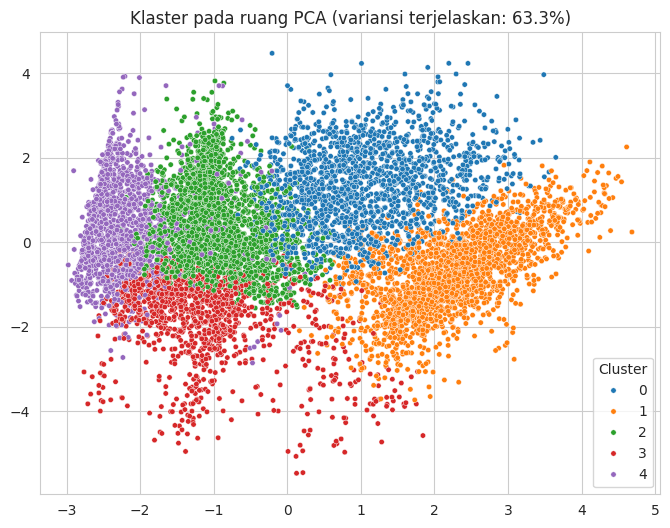

In [16]:
# Visualisasi 2D dengan PCA
pca = PCA(n_components=2, random_state=RANDOM_STATE)
Z = pca.fit_transform(X_scaled)
plt.figure(figsize=(8, 6))
sns.scatterplot(x=Z[:,0], y=Z[:,1], hue=df['Cluster'], palette='tab10', s=15)
plt.title(f'Klaster pada ruang PCA (variansi terjelaskan: {pca.explained_variance_ratio_.sum():.1%})')
plt.show()

,BALANCE,PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS,PURCHASES_FREQUENCY,CASH_ADVANCE_FREQUENCY,PRC_FULL_PAYMENT,Jumlah,Persen (%)
Cluster,,,,,,,,,,
0,3137.62,1372.26,2532.19,5835.72,2839.20,0.64,0.33,0.04,1698,19.0
1,2174.15,10.49,1957.89,3927.67,1638.48,0.01,0.28,0.04,2184,24.4
2,1462.17,1555.66,9.52,4551.96,1683.97,0.68,0.01,0.03,2398,26.8
3,136.23,257.62,96.24,2852.82,266.09,0.41,0.02,0.07,1242,13.9
4,175.46,1803.39,30.00,5096.50,1921.28,0.80,0.01,0.75,1428,16.0


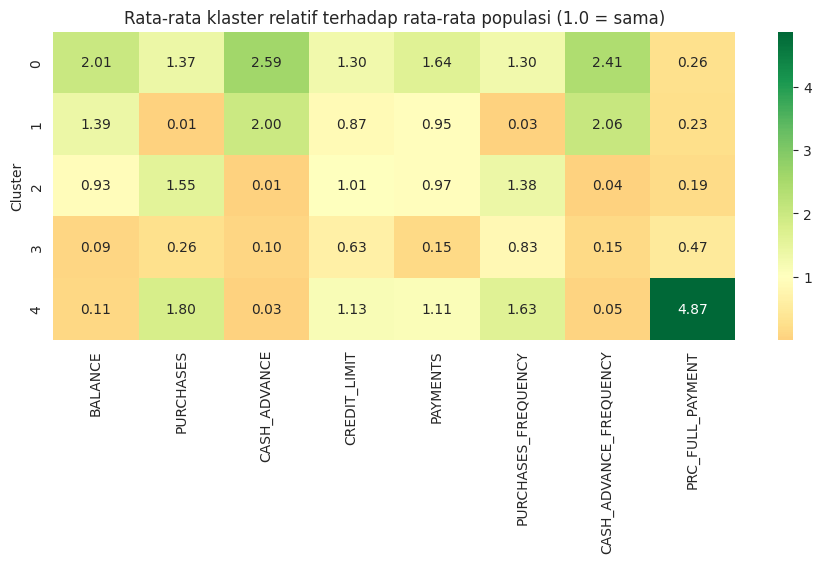

In [17]:
# Profil klaster (rata-rata nilai asli per klaster)
profile = df.groupby('Cluster')[FEATURES].mean().round(2)
profile['Jumlah'] = df['Cluster'].value_counts().sort_index()
profile['Persen (%)'] = (profile['Jumlah'] / len(df) * 100).round(1)
display(profile)

# Heatmap: nilai relatif terhadap rata-rata keseluruhan agar mudah dibaca
rel = df.groupby('Cluster')[FEATURES].mean() / df[FEATURES].mean()
plt.figure(figsize=(11, 4)); sns.heatmap(rel, annot=True, fmt='.2f', cmap='RdYlGn', center=1)
plt.title('Rata-rata klaster relatif terhadap rata-rata populasi (1.0 = sama)'); plt.show()

### Interpretasi klaster
> **Isi bagian ini setelah melihat tabel & heatmap di atas.** Beri nama tiap klaster berdasarkan profilnya (contoh pola yang *mungkin* muncul, tetapi harus dicocokkan dengan hasil Anda: nasabah pembelanja aktif, pengguna tarik tunai, nasabah pasif/saldo rendah). Jangan menyalin nama tanpa memeriksa datanya.

| Klaster | Nama segmen | Ciri utama | Rekomendasi tindakan |
|---|---|---|---|
| 0 | | | |
| 1 | | | |
| ... | | | |

**Keterbatasan:** hasil bergantung pada pemilihan fitur, transformasi log, dan `k`; klaster K-Means cenderung berbentuk bulat dan sensitif terhadap inisialisasi; tidak ada *ground truth* sehingga evaluasi bersifat internal.

## 6. Deployment
Model (pipeline lengkap) disimpan ke `cluster_model.joblib` beserta profil klaster dan rentang fitur, lalu dipakai oleh `app.py` (Streamlit).

In [18]:
ranges = {f: {'min': float(df[f].min()), 'max': float(df[f].quantile(0.99)), 'median': float(df[f].median())} for f in FEATURES}
bundle = {'model': model, 'features': FEATURES, 'profile': profile, 'ranges': ranges}
joblib.dump(bundle, 'cluster_model.joblib')
print('Tersimpan: cluster_model.joblib')

Tersimpan: cluster_model.joblib
